In [1]:
import pandas as pd

In [2]:
import numpy as np

In [6]:
df = pd.read_csv('cars_raw.csv')

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9379 entries, 0 to 9378
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   9379 non-null   int64  
 1   Make                   9379 non-null   object 
 2   Model                  9379 non-null   object 
 3   Used/New               9379 non-null   object 
 4   Price                  9379 non-null   object 
 5   ConsumerRating         9379 non-null   float64
 6   ConsumerReviews        9379 non-null   int64  
 7   SellerType             9379 non-null   object 
 8   SellerName             9379 non-null   object 
 9   SellerRating           9379 non-null   float64
 10  SellerReviews          9379 non-null   int64  
 11  StreetName             9379 non-null   object 
 12  State                  9379 non-null   object 
 13  Zipcode                9379 non-null   object 
 14  DealType               9157 non-null   object 
 15  Comf

In [8]:
df.isnull().sum()

Year                       0
Make                       0
Model                      0
Used/New                   0
Price                      0
ConsumerRating             0
ConsumerReviews            0
SellerType                 0
SellerName                 0
SellerRating               0
SellerReviews              0
StreetName                 0
State                      0
Zipcode                    0
DealType                 222
ComfortRating              0
InteriorDesignRating       0
PerformanceRating          0
ValueForMoneyRating        0
ExteriorStylingRating      0
ReliabilityRating          0
ExteriorColor              0
InteriorColor              0
Drivetrain                 0
MinMPG                     0
MaxMPG                     0
FuelType                   0
Transmission               0
Engine                     0
VIN                        0
Stock#                     0
Mileage                    0
dtype: int64

In [9]:
df["Used/New"].value_counts()

Used/New
Used                       7900
BMW Certified               247
Mercedes-Benz Certified     223
Honda Certified             208
Toyota Certified            153
Cadillac Certified          105
Ford Certified               71
Subaru Certified             58
Jeep Certified               55
Nissan Certified             50
Acura Certified              47
Chevrolet Certified          40
Kia Certified                34
INFINITI Certified           34
Volvo Certified              33
Porsche Certified            25
RAM Certified                24
Buick Certified              20
Volkswagen Certified         17
GMC Certified                13
Dodge Certified              10
Alfa Romeo Certified          7
Bentley Certified             2
MINI Certified                1
Ferrari Certified             1
Maserati Certified            1
Name: count, dtype: int64

In [10]:
for col in df.columns:
    print(f"\nColumn: {col}")
    
    if pd.api.types.is_numeric_dtype(df[col]):
        col_data = df[col].dropna()
        print(f"  Mean: {col_data.mean():.2f}")
        print(f"  Median: {col_data.median():.2f}")
        print(f"  Variance: {col_data.var():.2f}")
        print(f"  Standard Deviation: {col_data.std():.2f}")
        
    else:
        value_counts = df[col].value_counts()
        percentages = df[col].value_counts(normalize=True) * 100
        result = pd.DataFrame({'Frequency': value_counts, 'Percentage (%)': percentages.round(2)})
        print(result.head(10))


Column: Year
  Mean: 2018.72
  Median: 2019.00
  Variance: 4.94
  Standard Deviation: 2.22

Column: Make
               Frequency  Percentage (%)
Make                                    
BMW                  944           10.07
Mercedes-Benz        810            8.64
Toyota               797            8.50
Honda                713            7.60
Ford                 580            6.18
Jeep                 495            5.28
Lexus                484            5.16
Audi                 424            4.52
Chevrolet            416            4.44
Subaru               310            3.31

Column: Model
                        Frequency  Percentage (%)
Model                                            
Grand Cherokee Limited        266            2.84
CR-V EX-L                     189            2.02
X5 xDrive40i                  164            1.75
XT5 Luxury                    142            1.51
RAV4 LE                       112            1.19
GX 460 Base                   111    

In [11]:
import seaborn as sns

In [13]:
import matplotlib.pyplot as plt

C:\Users\USER\AppData\Local\Temp\ipykernel_8996\1650915580.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SellerType', data=df, palette='pastel')


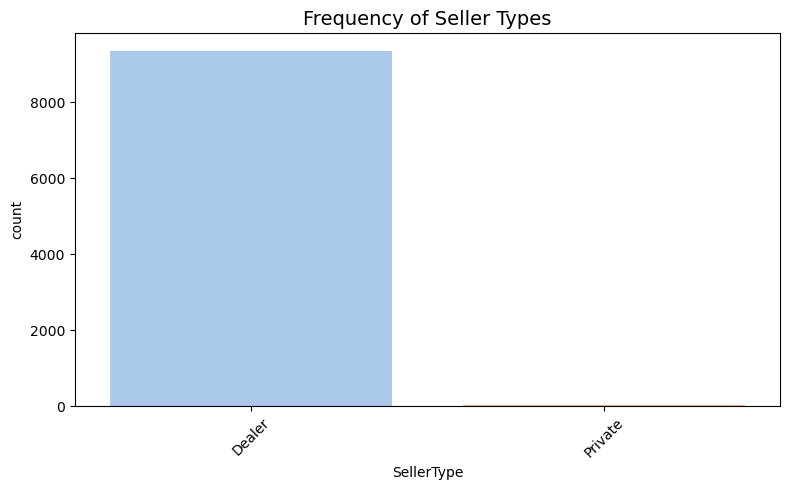

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x='SellerType', data=df, palette='pastel')  
plt.title('Frequency of Seller Types', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

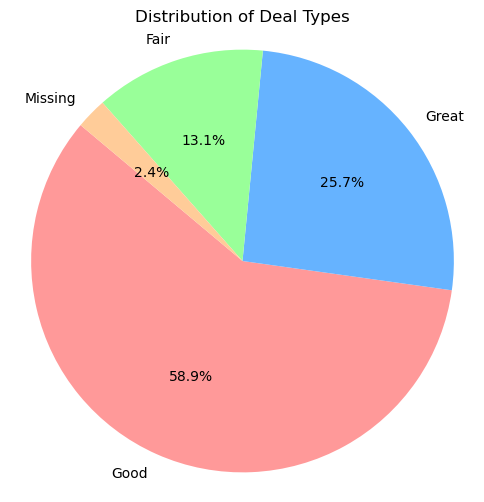

In [16]:
df['DealType'] = df['DealType'].fillna('Missing')
deal_counts = df['DealType'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0'] 
plt.figure(figsize=(6, 6))
plt.pie(deal_counts, labels=deal_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Distribution of Deal Types")
plt.axis('equal')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_8996\457154296.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


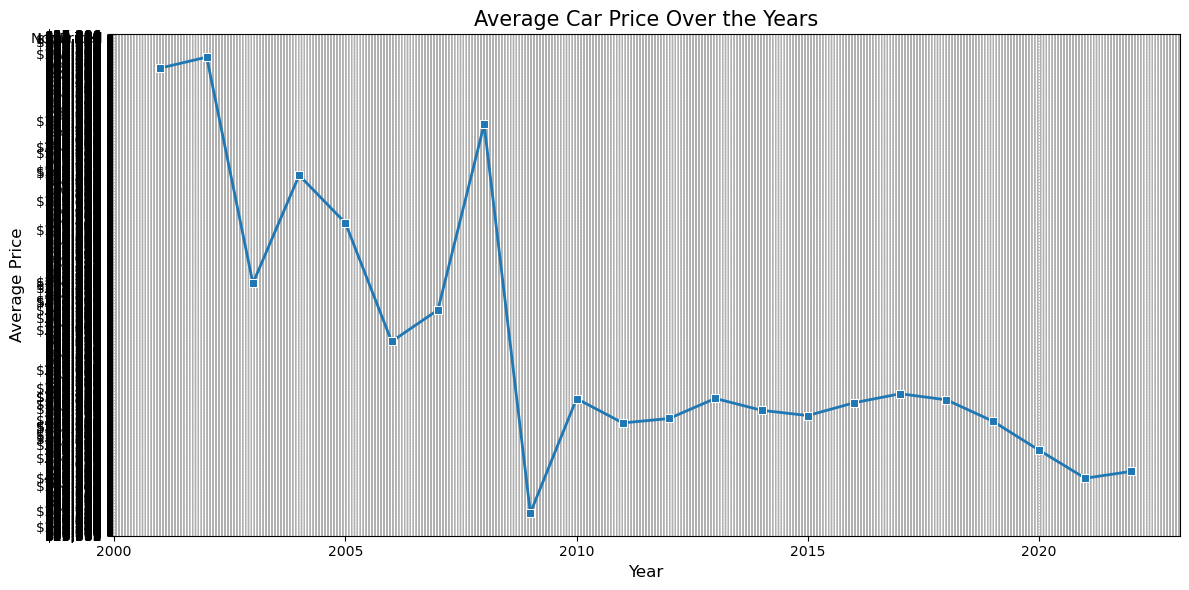

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='Year',
    y='Price',
    data=df,
    estimator='mean',
    ci=None,
    marker='s',              
    linewidth=2,             
)
plt.title('Average Car Price Over the Years', fontsize=15, fontweight='medium')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.grid(True, linestyle=':')  
plt.tight_layout()
plt.show()

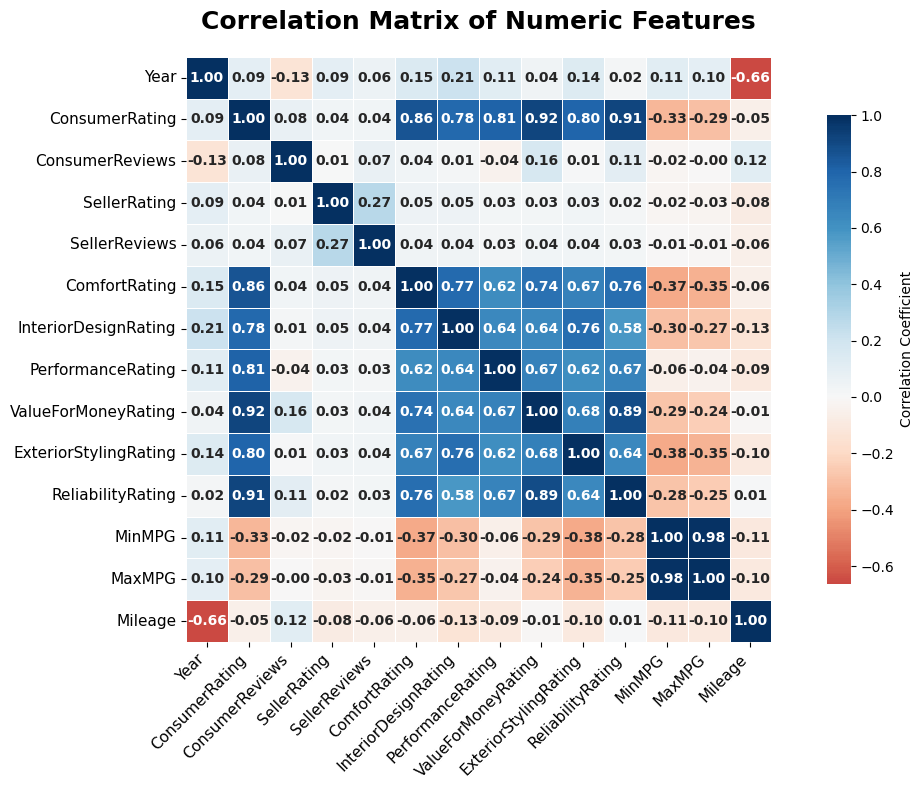

In [18]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu',                  
    center=0,
    linewidths=0.6,
    linecolor='white',              
    square=True,
    cbar_kws={
        'shrink': 0.8,
        'label': 'Correlation Coefficient'
    },
    annot_kws={"size": 10, "weight": "bold"}  
)

plt.title('Correlation Matrix of Numeric Features', fontsize=18, fontweight='semibold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_9644\3547256795.py:9: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USER\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


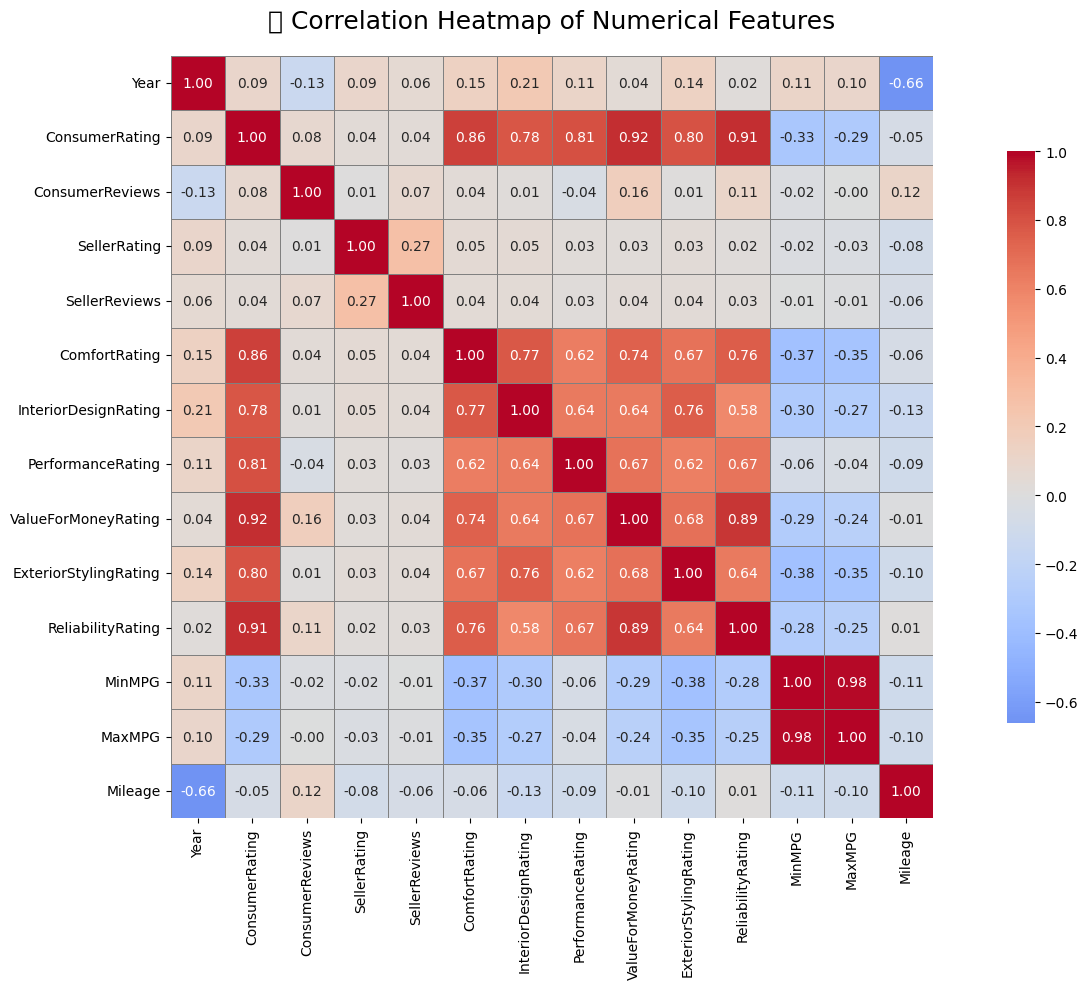

In [63]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_cols.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='gray', square=True, cbar_kws={'shrink': 0.75})

plt.title('🔍 Correlation Heatmap of Numerical Features', fontsize=18, pad=20)

plt.tight_layout()
plt.show()
